# Q-learning vs SARSA - Full Scenario Comparison

This notebook analyzes the **updated tabular experiments** where Q-learning and SARSA were run across the full assignment matrix (4 scenarios):

1. **Discrete / Min steps** (`MountainCar-v0`, baseline step cost)
2. **Continuous / Min fuel** (`MountainCarContinuous-v0`, quadratic fuel cost)
3. **Discrete / Min fuel** (discrete fuel-cost wrapper)
4. **Continuous / Min time** (continuous linear action-cost wrapper)

---

## Why this notebook was expanded

The first version only compared one discrete setup. The assignment requires studying behavior under different reward/cost formulations and action-space regimes. This version therefore:

- compares both algorithms across all required scenarios,
- visualizes reward, success, and episode-length trade-offs,
- shows training-curve dynamics,
- inspects saved model artifacts (`.npz` Q-tables + policy tables),
- provides interpretation-focused comments to support the report/presentation.

---

## How to read the results

- **Mean reward** reflects optimization under each scenario-specific reward design.
- **Success rate** indicates how often the car reaches the goal before truncation.
- **Mean episode length** helps interpret efficiency (lower is usually better when success is high).
- **Model diagnostics** (Q-value spread + policy maps) show *what kind of policy was learned*, not only final scalar metrics.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs" / "logs").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root with outputs/logs and README.md")


PROJECT_ROOT = find_project_root(Path.cwd())
LOGS_DIR = PROJECT_ROOT / "outputs" / "logs"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_EXPERIMENTS = {
    "discrete_minsteps": {
        "q_learning": "q_learning_discrete",
        "sarsa": "sarsa_discrete",
    },
    "discrete_minfuel": {
        "q_learning": "q_learning_discrete_minfuel",
        "sarsa": "sarsa_discrete_minfuel",
    },
    "continuous_minfuel": {
        "q_learning": "q_learning_continuous_minfuel",
        "sarsa": "sarsa_continuous_minfuel",
    },
    "continuous_mintime": {
        "q_learning": "q_learning_continuous_mintime",
        "sarsa": "sarsa_continuous_mintime",
    },
}


def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


aggregate_rows = []
seed_rows = []

for scenario, mapping in SCENARIO_EXPERIMENTS.items():
    for algo, exp in mapping.items():
        agg_path = LOGS_DIR / f"{exp}_aggregate.json"
        seed_path = LOGS_DIR / f"{exp}_seed_results.csv"

        if agg_path.exists():
            row = load_json(agg_path)
            row["scenario"] = scenario
            row["algorithm"] = algo
            row["experiment_name"] = exp
            aggregate_rows.append(row)

        if seed_path.exists():
            df = pd.read_csv(seed_path)
            df["scenario"] = scenario
            df["algorithm"] = algo
            df["experiment_name"] = exp
            seed_rows.append(df)

aggregate_df = pd.DataFrame(aggregate_rows)
seed_df = pd.concat(seed_rows, ignore_index=True) if seed_rows else pd.DataFrame()

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded aggregates: {len(aggregate_df)}")
print(f"Loaded seed rows: {len(seed_df)}")

display(
    aggregate_df[
        [
            "scenario",
            "algorithm",
            "mean_reward",
            "mean_success_rate",
            "mean_episode_length",
            "n_seeds",
        ]
    ].sort_values(["scenario", "algorithm"]).reset_index(drop=True)
)

Project root: C:\Users\hugok\OneDrive\Dokumenty\GitHub\mountain-pendulum
Loaded aggregates: 7
Loaded seed rows: 21


,scenario,algorithm,mean_reward,mean_success_rate,mean_episode_length,n_seeds
0,continuous_minfuel,q_learning,125.860522,0.746333,461.472889,3
1,continuous_minfuel,sarsa,163.216900,0.901333,345.550778,3
2,continuous_mintime,q_learning,118.271628,0.731889,472.944889,3
3,continuous_mintime,sarsa,163.638489,0.913444,324.430889,3
4,discrete_minfuel,q_learning,-144.121222,0.238667,192.787889,3
5,discrete_minfuel,sarsa,-116.278222,0.350444,187.233778,3
6,discrete_minsteps,sarsa,-195.349500,0.188500,NaN,3


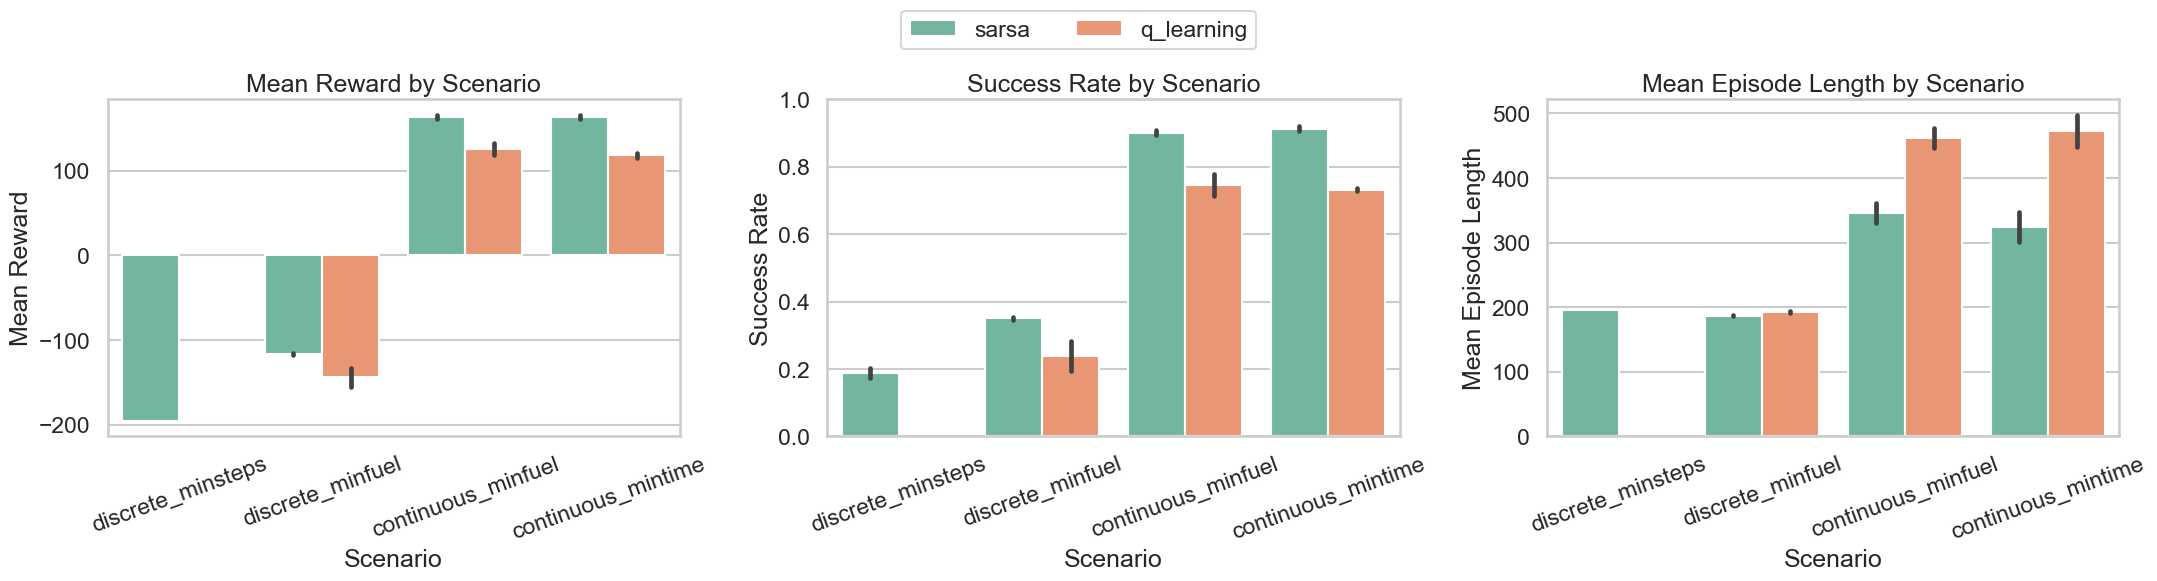

Saved: C:\Users\hugok\OneDrive\Dokumenty\GitHub\mountain-pendulum\outputs\figures\q_learning_sarsa_all_scenarios_bar_summary.png


In [3]:
plot_df = seed_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    data=plot_df,
    x="scenario",
    y="mean_reward",
    hue="algorithm",
    errorbar="sd",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Mean Reward by Scenario")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Mean Reward")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=plot_df,
    x="scenario",
    y="success_rate",
    hue="algorithm",
    errorbar="sd",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Success Rate by Scenario")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Success Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=plot_df,
    x="scenario",
    y="mean_episode_length",
    hue="algorithm",
    errorbar="sd",
    palette="Set2",
    ax=axes[2],
)
axes[2].set_title("Mean Episode Length by Scenario")
axes[2].set_xlabel("Scenario")
axes[2].set_ylabel("Mean Episode Length")
axes[2].tick_params(axis="x", rotation=20)

# Keep one legend per figure for readability.
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
out_path = FIG_DIR / "q_learning_sarsa_all_scenarios_bar_summary.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

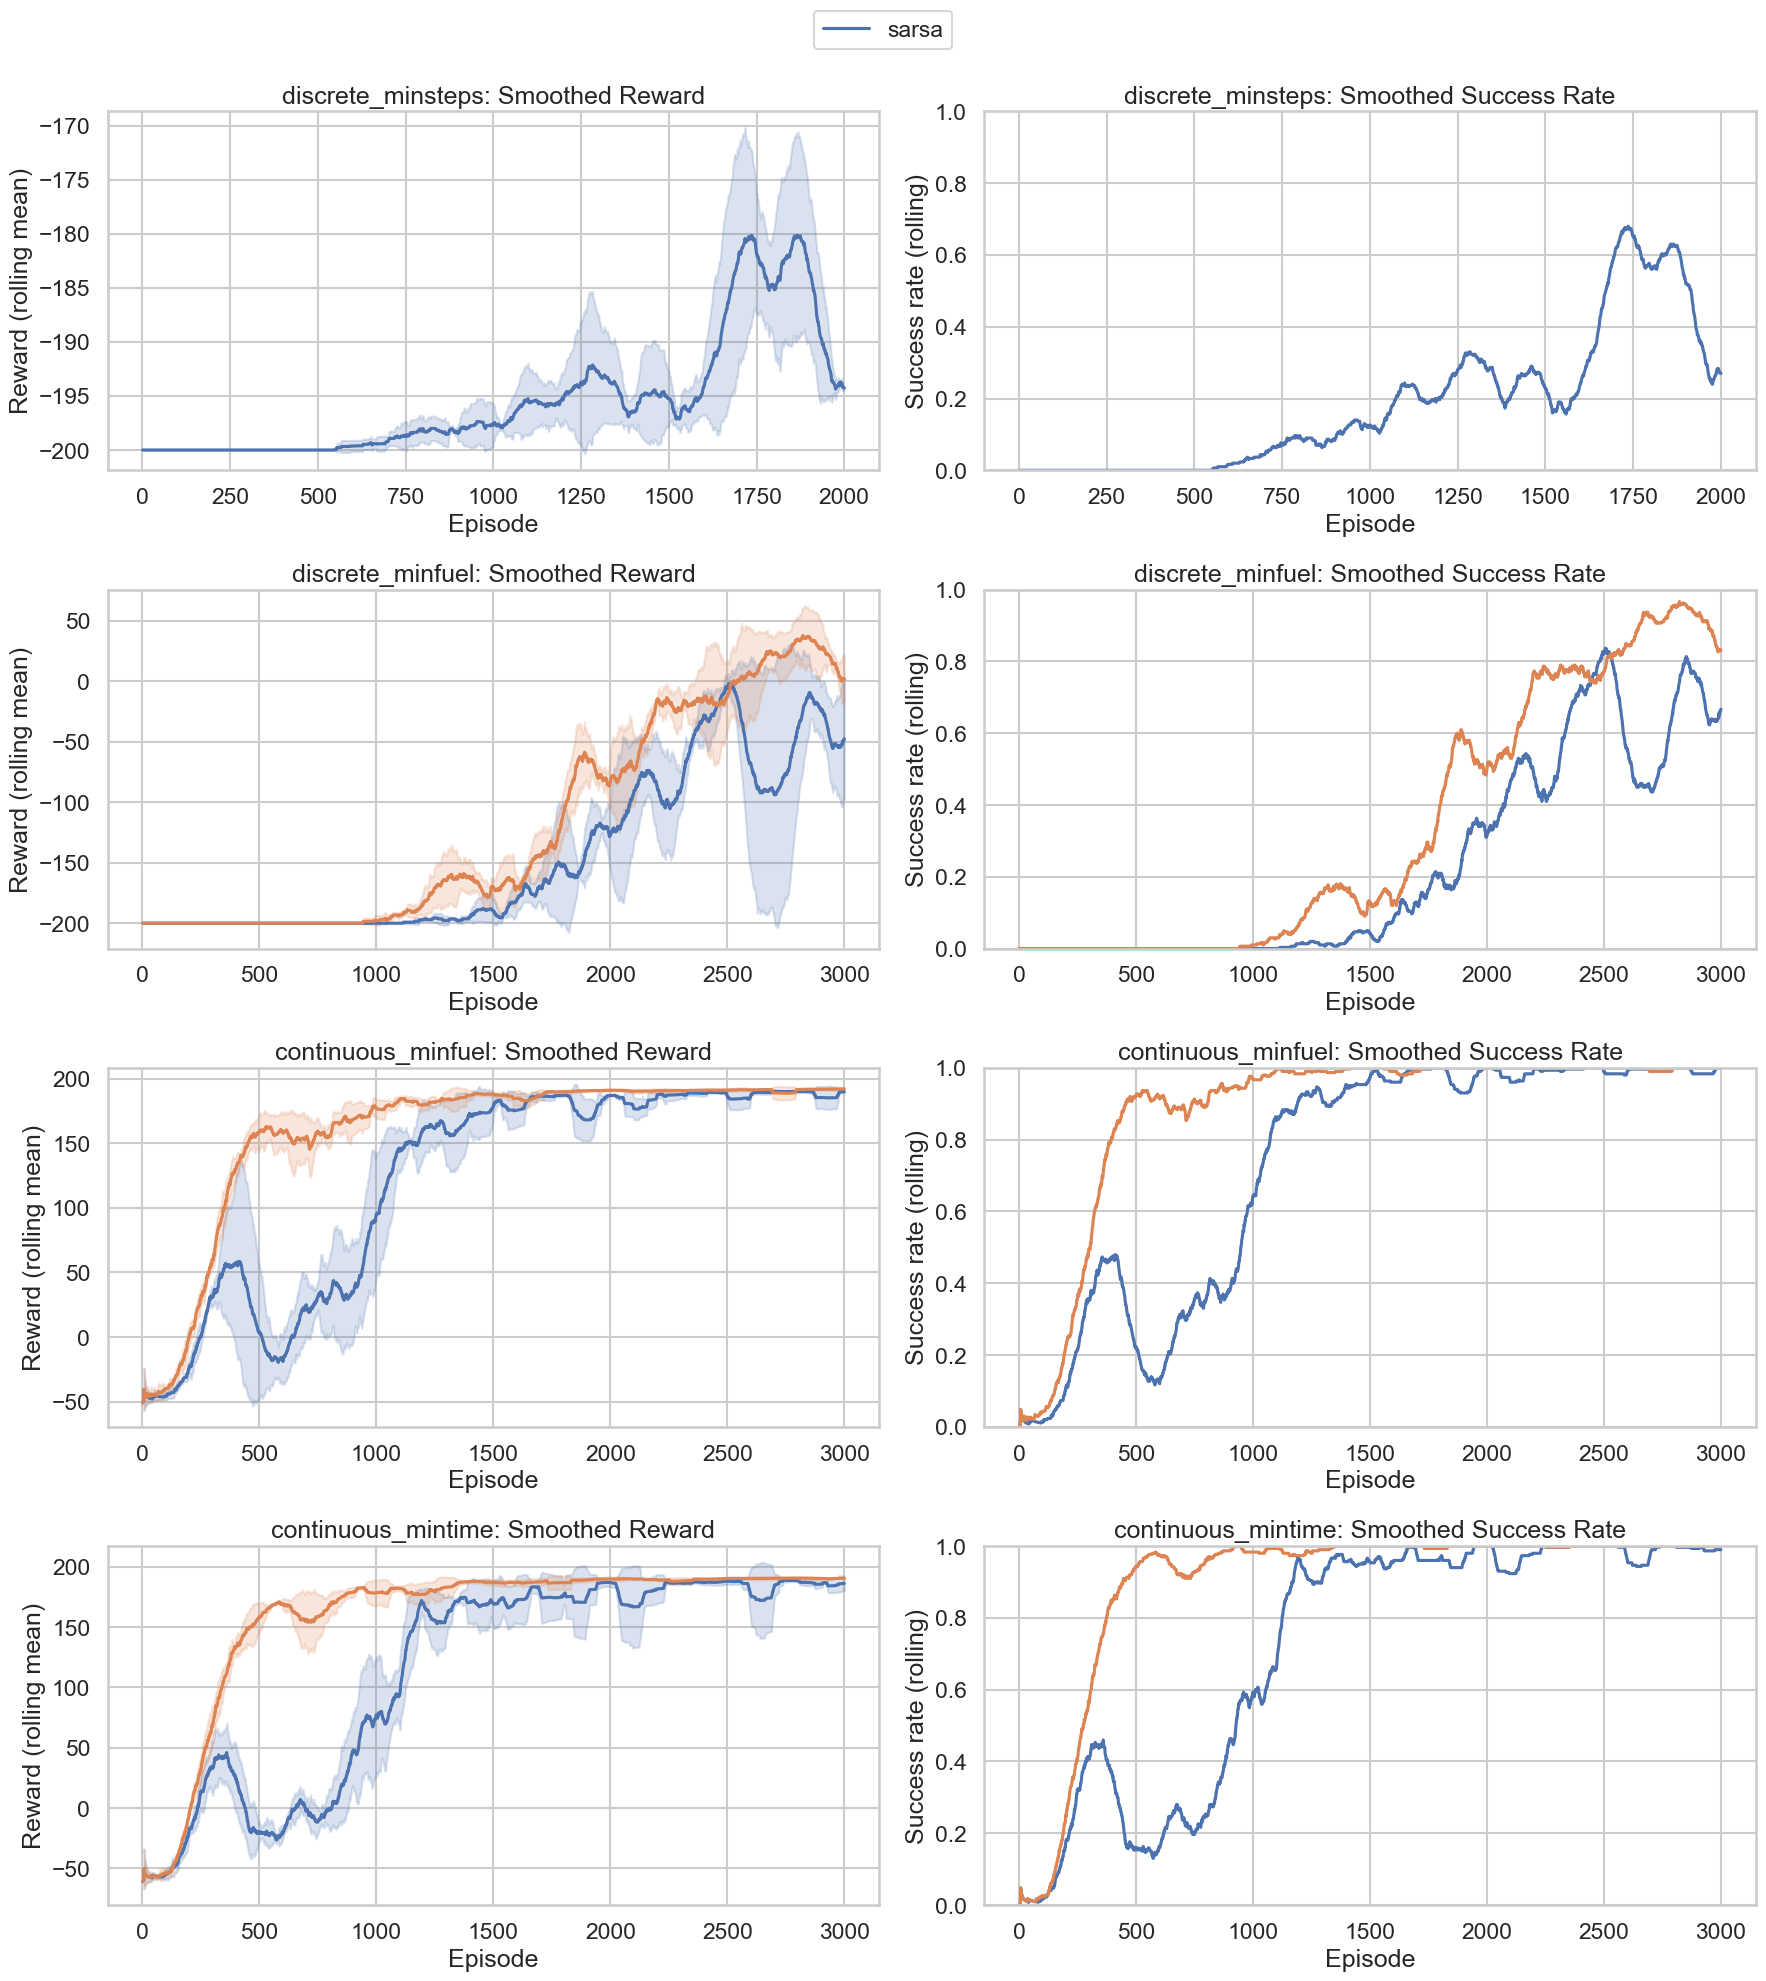

Saved: C:\Users\hugok\OneDrive\Dokumenty\GitHub\mountain-pendulum\outputs\figures\q_learning_sarsa_all_scenarios_learning_curves.png


In [4]:
def load_episode_curves(exp_name: str, seeds: list[int], scenario: str, algo: str) -> pd.DataFrame:
    frames = []
    for seed in seeds:
        path = LOGS_DIR / f"{exp_name}_seed{seed}_episodes.csv"
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df["scenario"] = scenario
        df["algorithm"] = algo
        df["experiment_name"] = exp_name
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


episode_frames = []
for scenario, mapping in SCENARIO_EXPERIMENTS.items():
    for algo, exp in mapping.items():
        rows = seed_df[(seed_df["scenario"] == scenario) & (seed_df["algorithm"] == algo)]
        seeds = sorted(rows["seed"].unique().tolist())
        ep_df = load_episode_curves(exp, seeds, scenario, algo)
        if len(ep_df):
            episode_frames.append(ep_df)

episodes_df = pd.concat(episode_frames, ignore_index=True)
episodes_df = episodes_df.sort_values(["scenario", "algorithm", "seed", "episode"]).reset_index(drop=True)

# Rolling smoothing clarifies trend while preserving seed-level variance.
episodes_df["reward_smooth"] = episodes_df.groupby(["scenario", "algorithm", "seed"])["reward"].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

success_by_ep = episodes_df.groupby(["scenario", "algorithm", "episode"], as_index=False)["success"].mean()
success_by_ep["success_smooth"] = success_by_ep.groupby(["scenario", "algorithm"])["success"].transform(
    lambda x: x.rolling(window=100, min_periods=1).mean()
)

scenarios = list(SCENARIO_EXPERIMENTS.keys())
fig, axes = plt.subplots(len(scenarios), 2, figsize=(18, 5 * len(scenarios)), sharex=False)

for i, scenario in enumerate(scenarios):
    left_ax = axes[i, 0]
    right_ax = axes[i, 1]

    cur = episodes_df[episodes_df["scenario"] == scenario]
    sns.lineplot(
        data=cur,
        x="episode",
        y="reward_smooth",
        hue="algorithm",
        estimator="mean",
        errorbar="sd",
        ax=left_ax,
    )
    left_ax.set_title(f"{scenario}: Smoothed Reward")
    left_ax.set_xlabel("Episode")
    left_ax.set_ylabel("Reward (rolling mean)")

    cur_s = success_by_ep[success_by_ep["scenario"] == scenario]
    sns.lineplot(
        data=cur_s,
        x="episode",
        y="success_smooth",
        hue="algorithm",
        estimator="mean",
        errorbar="sd",
        ax=right_ax,
    )
    right_ax.set_title(f"{scenario}: Smoothed Success Rate")
    right_ax.set_xlabel("Episode")
    right_ax.set_ylabel("Success rate (rolling)")
    right_ax.set_ylim(0, 1)

    if left_ax.get_legend() is not None:
        left_ax.get_legend().remove()
    if right_ax.get_legend() is not None:
        right_ax.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_path = FIG_DIR / "q_learning_sarsa_all_scenarios_learning_curves.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [5]:
def resolve_model_path(raw_path: str) -> Path:
    p = Path(raw_path)
    if p.exists():
        return p
    if p.suffix == "":
        p_npz = Path(str(p) + ".npz")
        if p_npz.exists():
            return p_npz
    raise FileNotFoundError(f"Model artifact not found: {raw_path}")


def load_best_seed_summary(exp_name: str) -> dict | None:
    seed_path = LOGS_DIR / f"{exp_name}_seed_results.csv"
    if not seed_path.exists():
        return None

    seed_results = pd.read_csv(seed_path)
    if seed_results.empty:
        return None

    best = seed_results.sort_values("mean_reward", ascending=False).iloc[0]
    seed = int(best["seed"])
    summary_path = LOGS_DIR / f"{exp_name}_seed{seed}_summary.json"
    if not summary_path.exists():
        return None

    summary = load_json(summary_path)
    summary["seed"] = seed
    summary["experiment_name"] = exp_name
    return summary


model_rows = []
missing_models = []
for scenario, mapping in SCENARIO_EXPERIMENTS.items():
    for algo, exp in mapping.items():
        summary = load_best_seed_summary(exp)
        if summary is None:
            missing_models.append((scenario, algo, exp, "missing seed_results/summary"))
            continue

        try:
            model_path = resolve_model_path(summary["model_path"])
            model_npz = np.load(model_path)
            q_table = model_npz["q_table"]
        except Exception as exc:
            missing_models.append((scenario, algo, exp, str(exc)))
            continue

        row = {
            "scenario": scenario,
            "algorithm": algo,
            "seed": summary["seed"],
            "q_table_shape": str(tuple(q_table.shape)),
            "q_min": float(q_table.min()),
            "q_max": float(q_table.max()),
            "q_mean": float(q_table.mean()),
            "q_std": float(q_table.std()),
            "epsilon_saved": float(model_npz["epsilon"]),
            "model_file": str(model_path),
            "policy_file": summary.get("policy_path", ""),
        }
        model_rows.append(row)

model_df = pd.DataFrame(model_rows).sort_values(["scenario", "algorithm"]).reset_index(drop=True)
display(model_df)

if missing_models:
    print("Skipped model diagnostics for unavailable artifacts:")
    for item in missing_models:
        print("-", item)

# Q-value spread plot: broader spread often means clearer action preferences.
if not model_df.empty:
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(data=model_df, x="scenario", y="q_std", hue="algorithm", palette="Set2", ax=ax)
    ax.set_title("Q-table Value Spread (Best Seed per Scenario)")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Std of Q-values")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    out_path = FIG_DIR / "q_learning_sarsa_qtable_spread.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

# Compact interpretation summary for report text.
summary_table = aggregate_df[["scenario", "algorithm", "mean_reward", "mean_success_rate", "mean_episode_length"]].copy()
summary_table = summary_table.sort_values(["scenario", "algorithm"]).reset_index(drop=True)
display(summary_table)

for scenario in SCENARIO_EXPERIMENTS:
    cur = summary_table[summary_table["scenario"] == scenario].set_index("algorithm")
    if {"q_learning", "sarsa"}.issubset(cur.index):
        reward_gap = cur.loc["sarsa", "mean_reward"] - cur.loc["q_learning", "mean_reward"]
        success_gap = cur.loc["sarsa", "mean_success_rate"] - cur.loc["q_learning", "mean_success_rate"]
        print(f"{scenario}: reward_gap(sarsa-q_learning)={reward_gap:.3f}, success_gap={success_gap:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hugok\\OneDrive\\Dokumenty\\GitHub\\mountain-pendulum\\outputs\\logs\\q_learning_discrete_seed_results.csv'

## Reproducibility: session run log + final metrics table

This section explicitly parses the session log file generated during the run:

- `outputs/logs/tabular_scenarios_run.log`

It extracts every `AGGREGATE` block (Q-learning and SARSA for each scenario), then merges those values with the historical baseline (`discrete_minsteps`) so the final table reflects the full **4-scenario x 2-algorithm** matrix.

This is the section you can directly screenshot/cite in the report.

In [ ]:
import re

run_log_path = LOGS_DIR / "tabular_scenarios_run.log"
text = run_log_path.read_text(encoding="utf-8") if run_log_path.exists() else ""

agg_blocks = re.findall(r"AGGREGATE:\s*(\{.*?\})", text, flags=re.DOTALL)
rows = []
for block in agg_blocks:
    d = json.loads(block)
    exp = d.get("experiment_name", "")
    # Map experiment_name -> scenario key used in notebook
    if exp.endswith("discrete_minfuel"):
        scenario = "discrete_minfuel"
    elif exp.endswith("continuous_minfuel"):
        scenario = "continuous_minfuel"
    elif exp.endswith("continuous_mintime"):
        scenario = "continuous_mintime"
    elif exp.endswith("_discrete"):
        scenario = "discrete_minsteps"
    else:
        scenario = "unknown"

    rows.append(
        {
            "scenario": scenario,
            "algorithm": d.get("algorithm"),
            "experiment_name": exp,
            "mean_reward": d.get("mean_reward"),
            "mean_success_rate": d.get("mean_success_rate"),
            "mean_episode_length": d.get("mean_episode_length", np.nan),
            "n_seeds": d.get("n_seeds", np.nan),
            "source": "tabular_scenarios_run.log",
        }
    )

runlog_df = pd.DataFrame(rows)

# Baseline scenario (discrete_minsteps) may come from prior runs.
baseline_df = aggregate_df[aggregate_df["scenario"] == "discrete_minsteps"].copy()
if len(baseline_df):
    baseline_df["source"] = "aggregate.json"

final_metrics_df = pd.concat(
    [
        baseline_df[
            [
                "scenario",
                "algorithm",
                "experiment_name",
                "mean_reward",
                "mean_success_rate",
                "mean_episode_length",
                "n_seeds",
                "source",
            ]
        ]
        if len(baseline_df)
        else pd.DataFrame(),
        runlog_df,
    ],
    ignore_index=True,
)

final_metrics_df = final_metrics_df.sort_values(["scenario", "algorithm"]).reset_index(drop=True)
display(final_metrics_df)

pivot_success = final_metrics_df.pivot(index="scenario", columns="algorithm", values="mean_success_rate")
pivot_reward = final_metrics_df.pivot(index="scenario", columns="algorithm", values="mean_reward")

print("Success-rate gaps (SARSA - Q-learning):")
if {"q_learning", "sarsa"}.issubset(pivot_success.columns):
    for scenario in pivot_success.index:
        q = pivot_success.loc[scenario, "q_learning"]
        s = pivot_success.loc[scenario, "sarsa"]
        print(f"- {scenario}: {s - q:+.4f}")

print("\nReward gaps (SARSA - Q-learning):")
if {"q_learning", "sarsa"}.issubset(pivot_reward.columns):
    for scenario in pivot_reward.index:
        q = pivot_reward.loc[scenario, "q_learning"]
        s = pivot_reward.loc[scenario, "sarsa"]
        print(f"- {scenario}: {s - q:+.4f}")

In [ ]:
# Dedicated figure from the final metrics table (easy to include in report)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=final_metrics_df,
    x="scenario",
    y="mean_success_rate",
    hue="algorithm",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Final Success Rate by Scenario")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("Mean Success Rate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=final_metrics_df,
    x="scenario",
    y="mean_reward",
    hue="algorithm",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Final Mean Reward by Scenario")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("Mean Reward")
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
out_path = FIG_DIR / "q_learning_sarsa_final_metrics_from_runlog.png"
plt.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")